# Task 1 — Pretrained Text-to-Image Model with Custom Dataset

## Objective

Use a pretrained Stable Diffusion text-to-image model and refine it using a
custom domain-specific dataset.

For this experiment, the selected domain is **animal imagery**.

The custom dataset will be derived from the Flickr8k dataset already used
in this project. A curated subset containing animal-related image-caption
pairs will be used for LoRA-based adaptation of the pretrained model.

## Internship Task

**Task 1:** Use a custom dataset to refine a pre-trained text-to-image
model such as DALL-E or Stable Diffusion. The model should be modified to
produce domain-specific visuals.

## Experimental Workflow

1. Verify the Colab GPU environment.
2. Install compatible text-to-image libraries.
3. Load and inspect the existing Flickr8k dataset.
4. Create a custom animal-imagery dataset.
5. Prepare image-caption pairs for training.
6. Load a pretrained Stable Diffusion model.
7. Generate baseline images before adaptation.
8. Fine-tune the model using LoRA.
9. Generate images using the adapted model.
10. Compare pretrained and adapted outputs.
11. Document results and limitations.

## Domain

**Animal imagery**

## Adaptation Method

**LoRA (Low-Rank Adaptation)**

## Evaluation

The pretrained and adapted models will be compared using:

- identical text prompts
- controlled random seeds
- baseline generated images
- adapted generated images
- side-by-side visual comparison
- qualitative prompt consistency analysis

The experiment will report the observed results and limitations rather than
assuming that fine-tuning automatically improves every output.

In [ ]:
# Task 1: Environment Verification

import sys
import platform
import torch

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("Operating system:", platform.system())
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory (GB):",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        )
    )
else:
    raise RuntimeError(
        "CUDA GPU is required for this experiment. "
        "Please enable a GPU runtime in Colab."
    )

Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch version: 2.11.0+cu128
Operating system: Linux
CUDA available: True
GPU: Tesla T4
GPU memory (GB): 14.56


In [ ]:
# Install compatible libraries

!pip install -q -U \
    diffusers \
    transformers \
    accelerate \
    peft \
    datasets \
    safetensors

In [ ]:
# Verify installed libraries

import torch
import diffusers
import transformers
import accelerate
import peft
import datasets

print("Environment verification")
print("-------------------------")
print("PyTorch:", torch.__version__)
print("Diffusers:", diffusers.__version__)
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("PEFT:", peft.__version__)
print("Datasets:", datasets.__version__)
print("CUDA:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is not available.")

print("GPU:", torch.cuda.get_device_name(0))
print("\nAll required libraries imported successfully.")

Environment verification
-------------------------
PyTorch: 2.11.0+cu128
Diffusers: 0.40.0
Transformers: 5.17.0
Accelerate: 1.15.0
PEFT: 0.21.0
Datasets: 5.0.1
CUDA: True
GPU: Tesla T4

All required libraries imported successfully.


In [2]:
# Set reproducibility and device

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda")

print("Device:", device)
print("Random seed:", SEED)
print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
Random seed: 42
GPU: Tesla T4


## Project Paths

All Task 1 experimental files will be stored under a dedicated project
directory.

The original Flickr8k dataset will remain unchanged.

In [3]:
# Create Task 1 project directories

PROJECT_ROOT = "/content/text_to_image_task1"

CUSTOM_DATASET_DIR = os.path.join(
    PROJECT_ROOT,
    "custom_animal_dataset"
)

TRAIN_DIR = os.path.join(
    PROJECT_ROOT,
    "training_data"
)

BASELINE_DIR = os.path.join(
    PROJECT_ROOT,
    "baseline_outputs"
)

ADAPTED_DIR = os.path.join(
    PROJECT_ROOT,
    "adapted_outputs"
)

LORA_OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "animal_lora"
)

for directory in [
    PROJECT_ROOT,
    CUSTOM_DATASET_DIR,
    TRAIN_DIR,
    BASELINE_DIR,
    ADAPTED_DIR,
    LORA_OUTPUT_DIR
]:
    os.makedirs(directory, exist_ok=True)

print("Project directories created.")
print("Project root:", PROJECT_ROOT)

Project directories created.
Project root: /content/text_to_image_task1


## Load Flickr8k

The project already uses Flickr8k in earlier tasks.

For Task 1, the original dataset will remain unchanged. We will create a
separate curated subset containing animal-related image-caption pairs.

This maintains continuity with the earlier project phases while creating a
domain-specific dataset for model adaptation.

In [3]:
# Task 1: Set up project directories

import os

PROJECT_ROOT = "/content/text_to_image_task1"

CUSTOM_DATASET_DIR = os.path.join(
    PROJECT_ROOT,
    "custom_animal_dataset"
)

TRAINING_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    "training_images"
)

BASELINE_OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "baseline_outputs"
)

ADAPTED_OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "adapted_outputs"
)

LORA_OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "lora_weights"
)

# Create all required directories
for directory in [
    PROJECT_ROOT,
    CUSTOM_DATASET_DIR,
    TRAINING_DATA_DIR,
    BASELINE_OUTPUT_DIR,
    ADAPTED_OUTPUT_DIR,
    LORA_OUTPUT_DIR
]:
    os.makedirs(directory, exist_ok=True)

print("Task 1 project structure is ready.")
print("----------------------------------")
print("Project root:", PROJECT_ROOT)
print("Custom dataset:", CUSTOM_DATASET_DIR)
print("Training images:", TRAINING_DATA_DIR)
print("Baseline outputs:", BASELINE_OUTPUT_DIR)
print("Adapted outputs:", ADAPTED_OUTPUT_DIR)
print("LoRA weights:", LORA_OUTPUT_DIR)

Task 1 project structure is ready.
----------------------------------
Project root: /content/text_to_image_task1
Custom dataset: /content/text_to_image_task1/custom_animal_dataset
Training images: /content/text_to_image_task1/training_images
Baseline outputs: /content/text_to_image_task1/baseline_outputs
Adapted outputs: /content/text_to_image_task1/adapted_outputs
LoRA weights: /content/text_to_image_task1/lora_weights


In [4]:
# Task 1: Verify the project directories

import os

directories = {
    "Project root": PROJECT_ROOT,
    "Custom dataset": CUSTOM_DATASET_DIR,
    "Training images": TRAINING_DATA_DIR,
    "Baseline outputs": BASELINE_OUTPUT_DIR,
    "Adapted outputs": ADAPTED_OUTPUT_DIR,
    "LoRA weights": LORA_OUTPUT_DIR,
}

print("Task 1 directory verification")
print("-----------------------------")

for name, path in directories.items():
    print(f"{name}: {path}")
    print("  Exists:", os.path.exists(path))

Task 1 directory verification
-----------------------------
Project root: /content/text_to_image_task1
  Exists: True
Custom dataset: /content/text_to_image_task1/custom_animal_dataset
  Exists: True
Training images: /content/text_to_image_task1/training_images
  Exists: True
Baseline outputs: /content/text_to_image_task1/baseline_outputs
  Exists: True
Adapted outputs: /content/text_to_image_task1/adapted_outputs
  Exists: True
LoRA weights: /content/text_to_image_task1/lora_weights
  Exists: True


## Create the Custom Animal Dataset

Animal-related examples will be selected from the Flickr8k training split.

The selected concepts include:

- dogs
- cats
- horses
- birds

The resulting custom dataset will contain:

- image
- caption
- domain

In [5]:
# Task 1: Define the custom animal dataset categories

animal_categories = {
    "dog": "a photo of a dog",
    "cat": "a photo of a cat",
    "horse": "a photo of a horse",
    "bird": "a photo of a bird"
}

print("Custom animal categories:")
print("-------------------------")

for category, caption in animal_categories.items():
    print(f"{category}: {caption}")

Custom animal categories:
-------------------------
dog: a photo of a dog
cat: a photo of a cat
horse: a photo of a horse
bird: a photo of a bird


In [8]:
# Task 1: Locate the downloaded animal dataset archive

import os
import glob

print("Searching for the downloaded animal dataset...")

zip_files = glob.glob(
    "/root/.cache/huggingface/hub/**/*.zip",
    recursive=True
)

if not zip_files:
    zip_files = glob.glob(
        "/content/**/*.zip",
        recursive=True
    )

print("ZIP files found:", len(zip_files))

for path in zip_files[:10]:
    print(path)

Searching for the downloaded animal dataset...
ZIP files found: 1
/root/.cache/huggingface/hub/datasets--AlvaroVasquezAI--Animal_Image_Classification_Dataset/snapshots/79b23706ea01d1cfecc7470fbf5cd2cd5a665165/cats_dogs_snakes.zip


In [9]:
# Task 1: Extract the downloaded animal dataset

import zipfile
import os

ANIMAL_ZIP_PATH = zip_files[0]
EXTRACT_DIR = os.path.join(PROJECT_ROOT, "animal_source")

os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Extracting animal dataset...")
print("ZIP:", ANIMAL_ZIP_PATH)

with zipfile.ZipFile(ANIMAL_ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("\nExtraction completed.")
print("Dataset location:", EXTRACT_DIR)

# Show the first few extracted items
for root, dirs, files in os.walk(EXTRACT_DIR):
    print("\nFolder:", root)
    print("Subfolders:", dirs[:10])
    print("Files:", files[:10])
    break

Extracting animal dataset...
ZIP: /root/.cache/huggingface/hub/datasets--AlvaroVasquezAI--Animal_Image_Classification_Dataset/snapshots/79b23706ea01d1cfecc7470fbf5cd2cd5a665165/cats_dogs_snakes.zip

Extraction completed.
Dataset location: /content/text_to_image_task1/animal_source

Folder: /content/text_to_image_task1/animal_source
Subfolders: ['dataset']
Files: []


In [10]:
# Task 1: Inspect the extracted animal dataset

import os

DATASET_ROOT = os.path.join(
    EXTRACT_DIR,
    "dataset"
)

print("Dataset root:", DATASET_ROOT)
print("\nContents:")

for item in sorted(os.listdir(DATASET_ROOT)):
    item_path = os.path.join(DATASET_ROOT, item)

    if os.path.isdir(item_path):
        files = os.listdir(item_path)
        print(f"\nFolder: {item}")
        print("Number of files:", len(files))
        print("First files:", files[:5])
    else:
        print("File:", item)

Dataset root: /content/text_to_image_task1/animal_source/dataset

Contents:

Folder: cats
Number of files: 1000
First files: ['0_0246.jpg', '0_0433.jpg', '0_0811.jpg', '0_0593.jpg', '0_0876.jpg']

Folder: dogs
Number of files: 1000
First files: ['1_0354.jpg', '1_0969.jpg', '1_0219.jpg', '1_0192.jpg', '1_0769.jpg']

Folder: snakes
Number of files: 1000
First files: ['2_0431.jpg', '2_0172.jpg', '2_0982.jpg', '2_0780.jpg', '2_0802.jpg']


In [11]:
# Task 1: Create text captions for the custom animal images

animal_captions = {
    "cats": "a photo of a cat",
    "dogs": "a photo of a dog",
    "snakes": "a photo of a snake"
}

print("Caption mapping:")
print("----------------")

for category, caption in animal_captions.items():
    print(f"{category}: {caption}")

Caption mapping:
----------------
cats: a photo of a cat
dogs: a photo of a dog
snakes: a photo of a snake


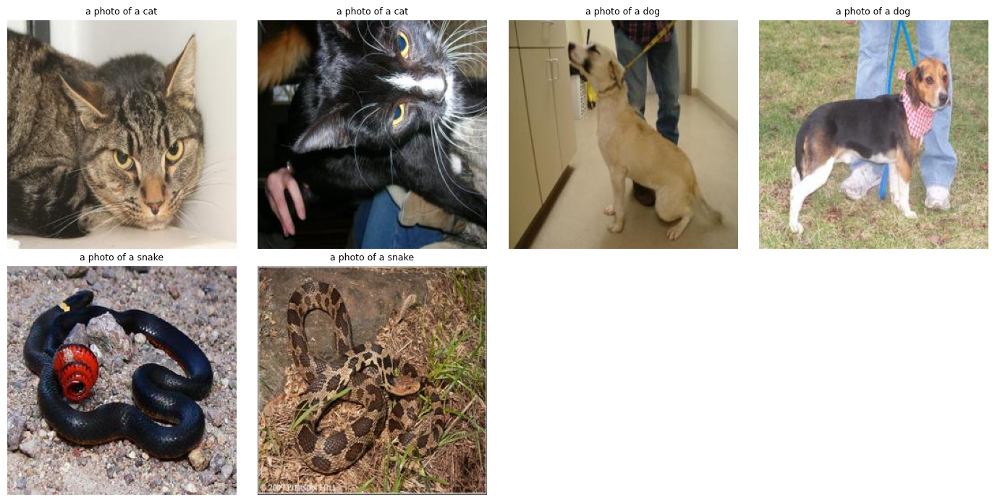

Sample visualization completed successfully.


In [13]:
# Task 1: Visualize samples from the custom animal dataset

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Use a local seed so this cell works independently
random.seed(42)

categories = ["cats", "dogs", "snakes"]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7)
)

axes = axes.flatten()

sample_index = 0

for category in categories:
    category_dir = os.path.join(DATASET_ROOT, category)

    image_files = [
        f for f in os.listdir(category_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    selected_files = random.sample(
        image_files,
        min(2, len(image_files))
    )

    for filename in selected_files:
        if sample_index >= len(axes):
            break

        image_path = os.path.join(category_dir, filename)
        image = Image.open(image_path).convert("RGB")

        axes[sample_index].imshow(image)
        axes[sample_index].set_title(
            animal_captions[category],
            fontsize=9
        )
        axes[sample_index].axis("off")

        sample_index += 1

for i in range(sample_index, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

print("Sample visualization completed successfully.")

In [14]:
# Task 1: Prepare a balanced custom training subset

import os
import shutil

TRAINING_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    "training_images"
)

os.makedirs(TRAINING_DATA_DIR, exist_ok=True)

# Number of images per category
IMAGES_PER_CATEGORY = 20

selected_count = 0

for category in ["cats", "dogs", "snakes"]:
    source_dir = os.path.join(DATASET_ROOT, category)

    image_files = sorted([
        f for f in os.listdir(source_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    selected_files = image_files[:IMAGES_PER_CATEGORY]

    for filename in selected_files:
        source_path = os.path.join(source_dir, filename)

        # Give each image a unique filename
        destination_filename = f"{category}_{filename}"
        destination_path = os.path.join(
            TRAINING_DATA_DIR,
            destination_filename
        )

        shutil.copy2(source_path, destination_path)
        selected_count += 1

print("Custom training subset prepared.")
print("-------------------------------")
print("Images per category:", IMAGES_PER_CATEGORY)
print("Categories:", 3)
print("Total training images:", selected_count)
print("Training directory:", TRAINING_DATA_DIR)

Custom training subset prepared.
-------------------------------
Images per category: 20
Categories: 3
Total training images: 60
Training directory: /content/text_to_image_task1/training_images


In [15]:
# Task 1: Prepare a balanced custom training subset

import os
import shutil

TRAINING_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    "training_images"
)

os.makedirs(TRAINING_DATA_DIR, exist_ok=True)

IMAGES_PER_CATEGORY = 20

selected_count = 0

for category in ["cats", "dogs", "snakes"]:
    source_dir = os.path.join(DATASET_ROOT, category)

    image_files = sorted([
        f for f in os.listdir(source_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    selected_files = image_files[:IMAGES_PER_CATEGORY]

    for filename in selected_files:
        source_path = os.path.join(source_dir, filename)

        destination_filename = f"{category}_{filename}"
        destination_path = os.path.join(
            TRAINING_DATA_DIR,
            destination_filename
        )

        shutil.copy2(source_path, destination_path)
        selected_count += 1

print("Custom training subset prepared.")
print("-------------------------------")
print("Images per category:", IMAGES_PER_CATEGORY)
print("Categories:", 3)
print("Total training images:", selected_count)
print("Training directory:", TRAINING_DATA_DIR)

Custom training subset prepared.
-------------------------------
Images per category: 20
Categories: 3
Total training images: 60
Training directory: /content/text_to_image_task1/training_images


## Evaluation Prompts

A fixed set of animal-related prompts will be used for baseline and adapted
model generation.

The same prompts and controlled seeds will be used for both models.

In [16]:
# Task 1: Define fixed evaluation prompts

evaluation_prompts = [
    "a photo of a dog",
    "a photo of a cat",
    "a photo of a snake",
    "a photo of a dog sitting outdoors",
    "a photo of a cat sitting indoors",
    "a photo of a snake in nature"
]

print("Evaluation prompts:")
print("-------------------")

for i, prompt in enumerate(evaluation_prompts, start=1):
    print(f"{i}. {prompt}")

Evaluation prompts:
-------------------
1. a photo of a dog
2. a photo of a cat
3. a photo of a snake
4. a photo of a dog sitting outdoors
5. a photo of a cat sitting indoors
6. a photo of a snake in nature


## Load the Pretrained Stable Diffusion Model

The pretrained model used for this experiment is Stable Diffusion v1.5.

The model will first generate baseline images without adaptation.

Later, the same base model will be combined with the learned LoRA adapter.

In [18]:
# Task 1: Configure the pretrained Stable Diffusion model

import torch

MODEL_NAME = "stable-diffusion-v1-5/stable-diffusion-v1-5"

dtype = torch.float16

# Select the available device
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Stable Diffusion configuration")
print("------------------------------")
print("Model:", MODEL_NAME)
print("Device:", device)
print("Data type:", dtype)

Stable Diffusion configuration
------------------------------
Model: stable-diffusion-v1-5/stable-diffusion-v1-5
Device: cuda
Data type: torch.float16


In [19]:
# Task 1: Load the pretrained Stable Diffusion model

from diffusers import AutoPipelineForText2Image

print("Loading pretrained Stable Diffusion...")
print("Model:", MODEL_NAME)

pipeline = AutoPipelineForText2Image.from_pretrained(
    MODEL_NAME,
    torch_dtype=dtype
)

pipeline = pipeline.to(device)

# Memory optimization for a T4 GPU
pipeline.enable_attention_slicing()

print("\nPretrained Stable Diffusion loaded successfully.")
print("Device:", device)

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pretrained Stable Diffusion...
Model: stable-diffusion-v1-5/stable-diffusion-v1-5


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]


Pretrained Stable Diffusion loaded successfully.
Device: cuda


## Baseline Generation

Before fine-tuning, the pretrained Stable Diffusion model is evaluated using
the fixed evaluation prompts.

These outputs establish the baseline for later comparison.

In [20]:
# Task 1: Generate baseline images before adaptation

import os
import torch
from diffusers import AutoPipelineForText2Image

os.makedirs(BASELINE_OUTPUT_DIR, exist_ok=True)

baseline_images = []

print("Generating baseline images...")
print("----------------------------")

for i, prompt in enumerate(evaluation_prompts, start=1):
    generator = torch.Generator(device=device).manual_seed(42 + i)

    image = pipeline(
        prompt=prompt,
        num_inference_steps=20,
        guidance_scale=7.5,
        generator=generator
    ).images[0]

    output_path = os.path.join(
        BASELINE_OUTPUT_DIR,
        f"baseline_{i}.png"
    )

    image.save(output_path)
    baseline_images.append(image)

    print(f"{i}. Saved: {output_path}")

print("\nBaseline generation completed successfully.")

Generating baseline images...
----------------------------


  0%|          | 0/20 [00:00<?, ?it/s]

1. Saved: /content/text_to_image_task1/baseline_outputs/baseline_1.png


  0%|          | 0/20 [00:00<?, ?it/s]

2. Saved: /content/text_to_image_task1/baseline_outputs/baseline_2.png


...

4. Saved: /content/text_to_image_task1/baseline_outputs/baseline_4.png


  0%|          | 0/20 [00:00<?, ?it/s]

5. Saved: /content/text_to_image_task1/baseline_outputs/baseline_5.png


  0%|          | 0/20 [00:00<?, ?it/s]

6. Saved: /content/text_to_image_task1/baseline_outputs/baseline_6.png

Baseline generation completed successfully.


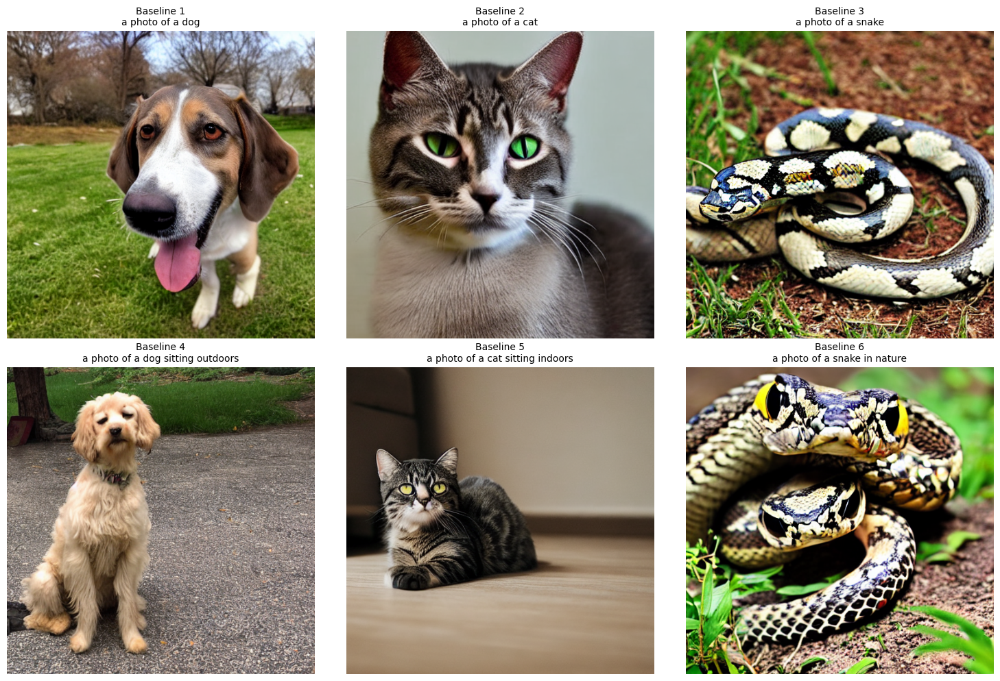

Baseline images displayed successfully.


In [21]:
# Task 1: Display baseline images

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10)
)

axes = axes.flatten()

for i, (ax, image, prompt) in enumerate(
    zip(axes, baseline_images, evaluation_prompts)
):
    ax.imshow(image)
    ax.set_title(
        f"Baseline {i + 1}\n{prompt}",
        fontsize=10
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Baseline images displayed successfully.")

## Prepare the Local Training Dataset

A controlled subset of the custom animal dataset will be prepared for LoRA
training.

Each training image will have a corresponding text caption.

The dataset will be stored locally in a format suitable for the Diffusers
training workflow.

In [22]:
# Task 1: Create the local LoRA training dataset

import os
import json

TRAINING_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    "training_images"
)

metadata = []

caption_map = {
    "cats": "a photo of a cat",
    "dogs": "a photo of a dog",
    "snakes": "a photo of a snake"
}

image_files = sorted([
    f for f in os.listdir(TRAINING_DATA_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

for filename in image_files:
    category = filename.split("_")[0]

    metadata.append({
        "file_name": filename,
        "text": caption_map[category]
    })

metadata_path = os.path.join(
    TRAINING_DATA_DIR,
    "metadata.jsonl"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:
    for item in metadata:
        f.write(json.dumps(item) + "\n")

print("LoRA training dataset prepared.")
print("------------------------------")
print("Training images:", len(image_files))
print("Captions:", len(metadata))
print("Metadata file:", metadata_path)

LoRA training dataset prepared.
------------------------------
Training images: 60
Captions: 60
Metadata file: /content/text_to_image_task1/training_images/metadata.jsonl


In [23]:
# Task 1: Verify the local LoRA training dataset

import os
import json

image_files = sorted([
    filename
    for filename in os.listdir(TRAINING_DATA_DIR)
    if filename.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Local training dataset verification")
print("-----------------------------------")
print("Image files:", len(image_files))
print(
    "Metadata exists:",
    os.path.exists(metadata_path)
)

print("\nFirst five image files:")
for filename in image_files[:5]:
    print(filename)

# Verify metadata entries
with open(metadata_path, "r", encoding="utf-8") as f:
    metadata_records = [
        json.loads(line)
        for line in f
    ]

print("\nMetadata records:", len(metadata_records))

print("\nFirst three metadata records:")
for record in metadata_records[:3]:
    print(record)

print("\nVerification completed successfully.")

Local training dataset verification
-----------------------------------
Image files: 60
Metadata exists: True

First five image files:
cats_0_0001.jpg
cats_0_0002.jpg
cats_0_0003.jpg
cats_0_0004.jpg
cats_0_0005.jpg

Metadata records: 60

First three metadata records:
{'file_name': 'cats_0_0001.jpg', 'text': 'a photo of a cat'}
{'file_name': 'cats_0_0002.jpg', 'text': 'a photo of a cat'}
{'file_name': 'cats_0_0003.jpg', 'text': 'a photo of a cat'}

Verification completed successfully.


## Install the Diffusers Training Example

The LoRA training stage uses the Diffusers text-to-image LoRA training
workflow.

The training script will be obtained from the Diffusers repository.

In [24]:
# Task 1: Locate the Diffusers LoRA training script

import diffusers
import os

print("Installed Diffusers version:", diffusers.__version__)

DIFFUSERS_TRAIN_SCRIPT = os.path.join(
    os.path.dirname(diffusers.__file__),
    "examples",
    "text_to_image",
    "train_text_to_image_lora.py"
)

print("Expected training script:")
print(DIFFUSERS_TRAIN_SCRIPT)

print(
    "\nTraining script exists:",
    os.path.exists(DIFFUSERS_TRAIN_SCRIPT)
)

Installed Diffusers version: 0.40.0
Expected training script:
/usr/local/lib/python3.13/dist-packages/diffusers/examples/text_to_image/train_text_to_image_lora.py

Training script exists: False


In [25]:
# Task 1: Download the matching Diffusers LoRA training script

import os
import requests
import diffusers

DIFFUSERS_VERSION = diffusers.__version__

TRAIN_SCRIPT_URL = (
    f"https://raw.githubusercontent.com/huggingface/diffusers/"
    f"v{DIFFUSERS_VERSION}/examples/text_to_image/train_text_to_image_lora.py"
)

DIFFUSERS_TRAIN_SCRIPT = os.path.join(
    PROJECT_ROOT,
    "train_text_to_image_lora.py"
)

response = requests.get(TRAIN_SCRIPT_URL, timeout=60)
response.raise_for_status()

with open(DIFFUSERS_TRAIN_SCRIPT, "w", encoding="utf-8") as f:
    f.write(response.text)

print("Diffusers version:", DIFFUSERS_VERSION)
print("Training script downloaded successfully.")
print("Training script:", DIFFUSERS_TRAIN_SCRIPT)
print("Script size:", os.path.getsize(DIFFUSERS_TRAIN_SCRIPT), "bytes")

Diffusers version: 0.40.0
Training script downloaded successfully.
Training script: /content/text_to_image_task1/train_text_to_image_lora.py
Script size: 43229 bytes


In [26]:
# Task 1: Configure Accelerate for the LoRA training run

import os
import yaml

ACCELERATE_CONFIG_DIR = os.path.expanduser(
    "~/.cache/huggingface/accelerate"
)

ACCELERATE_CONFIG_PATH = os.path.join(
    ACCELERATE_CONFIG_DIR,
    "default_config.yaml"
)

os.makedirs(
    ACCELERATE_CONFIG_DIR,
    exist_ok=True
)

accelerate_config = {
    "compute_environment": "LOCAL_MACHINE",
    "distributed_type": "NO",
    "mixed_precision": "fp16",
    "use_cpu": False,
    "debug": False,
    "machine_rank": 0,
    "num_machines": 1,
    "num_processes": 1,
    "main_process_ip": None,
    "main_process_port": None,
    "rdzv_conf": {},
    "same_network": False,
    "tpu_use_cluster": False,
    "tpu_use_sudo": False,
    "tpu_env": [],
    "downcast_bf16": "no",
    "enable_cpu_affinity": False,
    "dynamo_config": {},
    "deepspeed_config": {},
    "fsdp_config": {},
    "megatron_lm_config": {},
    "xpu_config": {}
}

with open(
    ACCELERATE_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as f:
    yaml.safe_dump(
        accelerate_config,
        f,
        sort_keys=False
    )

print("Accelerate configuration created.")
print("Configuration:", ACCELERATE_CONFIG_PATH)

Accelerate configuration created.
Configuration: /root/.cache/huggingface/accelerate/default_config.yaml


## LoRA Fine-Tuning Configuration

The custom dataset is relatively small, so the training configuration is
conservative.

The experiment uses:

- batch size of 1
- gradient accumulation
- gradient checkpointing
- FP16 mixed precision
- limited training steps
- LoRA rank of 4

The purpose is to demonstrate domain adaptation on a Colab GPU rather than
large-scale production training.

In [27]:
# Task 1: Prepare the LoRA training command

import os
import sys

TRAIN_SCRIPT = DIFFUSERS_TRAIN_SCRIPT

if not os.path.exists(TRAIN_SCRIPT):
    raise FileNotFoundError(
        f"Training script not found: {TRAIN_SCRIPT}"
    )

if not os.path.exists(TRAINING_DATA_DIR):
    raise FileNotFoundError(
        f"Training dataset not found: {TRAINING_DATA_DIR}"
    )

command = [
    sys.executable,
    TRAIN_SCRIPT,

    "--pretrained_model_name_or_path",
    MODEL_NAME,

    "--train_data_dir",
    TRAINING_DATA_DIR,

    "--caption_column",
    "text",

    "--resolution",
    "512",

    "--center_crop",

    "--random_flip",

    "--train_batch_size",
    "1",

    "--gradient_accumulation_steps",
    "4",

    "--gradient_checkpointing",

    "--mixed_precision",
    "fp16",

    "--max_train_steps",
    "300",

    "--learning_rate",
    "1e-4",

    "--lr_scheduler",
    "constant",

    "--lr_warmup_steps",
    "0",

    "--rank",
    "4",

    "--output_dir",
    LORA_OUTPUT_DIR,

    "--checkpointing_steps",
    "100",

    "--seed",
    "42"
]

print("LoRA training command prepared.")
print("--------------------------------")
print("Training script:", TRAIN_SCRIPT)
print("Training dataset:", TRAINING_DATA_DIR)
print("Training images:", len(image_files))
print("Output directory:", LORA_OUTPUT_DIR)
print("Training steps:", 300)
print("LoRA rank:", 4)

LoRA training command prepared.
--------------------------------
Training script: /content/text_to_image_task1/train_text_to_image_lora.py
Training dataset: /content/text_to_image_task1/training_images
Training images: 60
Output directory: /content/text_to_image_task1/lora_weights
Training steps: 300
LoRA rank: 4


In [1]:
# Task 1 — Force Python to use torchao 0.18.0

!pip uninstall -y torchao
!pip install --no-cache-dir --force-reinstall "torchao==0.18.0"

import sys
import subprocess

print("Python:", sys.executable)

result = subprocess.run(
    [sys.executable, "-m", "pip", "show", "torchao"],
    capture_output=True,
    text=True
)

print(result.stdout)

Found existing installation: torchao 0.18.0
Uninstalling torchao-0.18.0:
  Successfully uninstalled torchao-0.18.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 43.1 MB/s eta 0:00:00
Python: /usr/bin/python3
Name: torchao
Version: 0.18.0
Summary: Package for applying ao techniques to GPU models
Home-page: https://github.com/pytorch/ao
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.13/dist-packages
Requires: 
Required-by: 



In [2]:
import torchao
import peft
import diffusers

print("Final dependency check")
print("----------------------")
print("torchao:", torchao.__version__)
print("peft:", peft.__version__)
print("diffusers:", diffusers.__version__)
print("torchao location:", torchao.__file__)

Final dependency check
----------------------
torchao: 0.18.0
peft: 0.20.0
diffusers: 0.40.0
torchao location: /usr/local/lib/python3.13/dist-packages/torchao/__init__.py


In [3]:
# Task 1 — Recreate the LoRA training configuration

import os
import subprocess
import sys

TRAIN_SCRIPT = "/content/text_to_image_task1/train_text_to_image_lora.py"
TRAIN_DATA_DIR = "/content/text_to_image_task1/training_images"
LORA_OUTPUT_DIR = "/content/text_to_image_task1/lora_weights"

print("Training script exists:", os.path.exists(TRAIN_SCRIPT))
print("Training dataset exists:", os.path.exists(TRAIN_DATA_DIR))
print("Number of training images:", len([
    f for f in os.listdir(TRAIN_DATA_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]))
print("Output directory:", LORA_OUTPUT_DIR)

Training script exists: True
Training dataset exists: True
Number of training images: 60
Output directory: /content/text_to_image_task1/lora_weights


## Load the LoRA-Adapted Model

The original Stable Diffusion model will be loaded again as the base model.

The trained LoRA weights will then be attached to the base pipeline.

This keeps the pretrained model and the learned domain-specific adapter
separate.

In [8]:
# Task 1 — Fix Accelerate configuration and train LoRA

import os
import subprocess
import sys
import torch

# --------------------------------------------------
# Model and paths
# --------------------------------------------------

MODEL_NAME = "stable-diffusion-v1-5/stable-diffusion-v1-5"

TRAIN_SCRIPT = "/content/text_to_image_task1/train_text_to_image_lora.py"
TRAIN_DATA_DIR = "/content/text_to_image_task1/training_images"
LORA_OUTPUT_DIR = "/content/text_to_image_task1/lora_weights"

# --------------------------------------------------
# Create a clean Accelerate configuration
# --------------------------------------------------

accelerate_config = """compute_environment: LOCAL_MACHINE
debug: false
distributed_type: NO
downcast_bf16: "no"
enable_cpu_affinity: false
gpu_ids: "0"
machine_rank: 0
main_process_ip: null
main_process_port: null
main_training_function: main
mixed_precision: fp16
num_machines: 1
num_processes: 1
rdzv_backend: static
same_network: true
tpu_env: []
tpu_use_cluster: false
tpu_use_sudo: false
use_cpu: false
"""

config_dir = "/root/.cache/huggingface/accelerate"
config_path = os.path.join(config_dir, "default_config.yaml")

os.makedirs(config_dir, exist_ok=True)

with open(config_path, "w") as f:
    f.write(accelerate_config)

print("Clean Accelerate configuration created.")
print("Config:", config_path)

# --------------------------------------------------
# Verify important files
# --------------------------------------------------

print("\nEnvironment check")
print("-----------------")
print("Training script:", os.path.exists(TRAIN_SCRIPT))
print("Training dataset:", os.path.exists(TRAIN_DATA_DIR))
print("Training images:", len([
    f for f in os.listdir(TRAIN_DATA_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]))
print("CUDA available:", torch.cuda.is_available())

# --------------------------------------------------
# Training command
# --------------------------------------------------

train_command = [
    sys.executable,
    "-m",
    "accelerate.commands.launch",

    TRAIN_SCRIPT,

    "--pretrained_model_name_or_path",
    MODEL_NAME,

    "--train_data_dir",
    TRAIN_DATA_DIR,

    "--output_dir",
    LORA_OUTPUT_DIR,

    "--resolution",
    "512",

    "--center_crop",

    "--train_batch_size",
    "1",

    "--gradient_accumulation_steps",
    "4",

    "--gradient_checkpointing",

    "--mixed_precision",
    "fp16",

    "--learning_rate",
    "1e-4",

    "--lr_scheduler",
    "constant",

    "--lr_warmup_steps",
    "0",

    "--max_train_steps",
    "300",

    "--checkpointing_steps",
    "100",

    "--rank",
    "4",

    "--seed",
    "42",
]

# --------------------------------------------------
# Start training
# --------------------------------------------------

print("\nStarting LoRA training...")
print("=" * 60)

result = subprocess.run(
    train_command,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout)

print("=" * 60)
print("Training return code:", result.returncode)

if result.returncode == 0:
    print("SUCCESS: LoRA training completed.")
else:
    print("ERROR: LoRA training failed.")

Clean Accelerate configuration created.
Config: /root/.cache/huggingface/accelerate/default_config.yaml

Environment check
-----------------
Training script: True
Training dataset: True
Training images: 60
CUDA available: True

Starting LoRA training...
Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
09/23/2026 17:54:13 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

/usr/local/lib/python3.13/dist-packages

In [10]:
# Reload required imports and configuration after runtime restart

import torch
from diffusers import AutoPipelineForText2Image

MODEL_NAME = "stable-diffusion-v1-5/stable-diffusion-v1-5"
LORA_OUTPUT_DIR = "/content/text_to_image_task1/lora_weights"

dtype = torch.float16
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading LoRA-adapted Stable Diffusion...")

adapted_pipeline = AutoPipelineForText2Image.from_pretrained(
    MODEL_NAME,
    torch_dtype=dtype
)

adapted_pipeline.load_lora_weights(
    LORA_OUTPUT_DIR
)

adapted_pipeline = adapted_pipeline.to(device)

print("LoRA-adapted Stable Diffusion pipeline loaded successfully.")
print("Device:", device)
print("LoRA weights:", LORA_OUTPUT_DIR)

Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading LoRA-adapted Stable Diffusion...


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


LoRA-adapted Stable Diffusion pipeline loaded successfully.
Device: cuda
LoRA weights: /content/text_to_image_task1/lora_weights


In [13]:
# Generate adapted images

import os
import torch

# Restore paths/configuration after runtime restart
TASK1_DIR = "/content/text_to_image_task1"
ADAPTED_DIR = os.path.join(TASK1_DIR, "adapted_outputs")

os.makedirs(ADAPTED_DIR, exist_ok=True)

evaluation_prompts = [
    "a photo of a dog",
    "a photo of a cat",
    "a photo of a snake",
    "a photo of a dog sitting outdoors",
    "a photo of a cat sitting indoors",
    "a photo of a snake in nature"
]

SEED = 42

adapted_images = []

for i, prompt in enumerate(evaluation_prompts):

    generator = torch.Generator(
        device=device
    ).manual_seed(SEED + i)

    with torch.no_grad():
        result = adapted_pipeline(
            prompt=prompt,
            num_inference_steps=20,
            guidance_scale=7.5,
            generator=generator
        )

    image = result.images[0]
    adapted_images.append(image)

    image.save(
        os.path.join(
            ADAPTED_DIR,
            f"adapted_{i + 1}.png"
        )
    )

print("Adapted image generation completed.")
print("Number of images generated:", len(adapted_images))
print("Saved to:", ADAPTED_DIR)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Adapted image generation completed.
Number of images generated: 6
Saved to: /content/text_to_image_task1/adapted_outputs


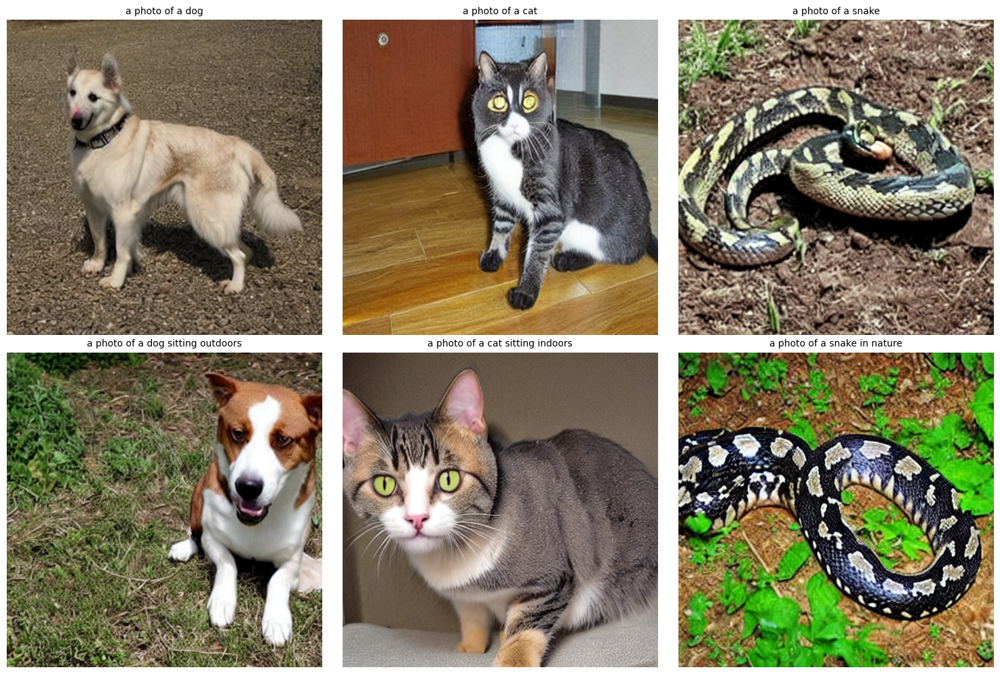

In [14]:
# Display adapted images

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, (ax, image, prompt) in enumerate(
    zip(axes.flat, adapted_images, evaluation_prompts)
):
    ax.imshow(image)
    ax.set_title(prompt, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Controlled Comparison

The same prompt and same random seed will be used for the pretrained and
LoRA-adapted models.

This provides a controlled qualitative comparison of the effect of domain
adaptation.

The comparison examines:

1. animal concept consistency
2. visual characteristics
3. changes introduced by LoRA
4. possible overfitting
5. preservation of prompt meaning

In [15]:
# Controlled baseline vs adapted comparison

import torch

comparison_prompt = "a dog running through a grassy field"
NUM_SAMPLES = 4

baseline_eval = []
adapted_eval = []

# Load the original pretrained pipeline if needed
if "pipeline" not in globals():
    print("Loading original pretrained pipeline for comparison...")

    pipeline = AutoPipelineForText2Image.from_pretrained(
        MODEL_NAME,
        torch_dtype=dtype
    )

    pipeline = pipeline.to(device)
    pipeline.enable_attention_slicing()

for i in range(NUM_SAMPLES):

    seed = SEED + 100 + i

    # Baseline
    generator = torch.Generator(
        device=device
    ).manual_seed(seed)

    with torch.no_grad():
        baseline_image = pipeline(
            prompt=comparison_prompt,
            num_inference_steps=20,
            guidance_scale=7.5,
            generator=generator
        ).images[0]

    # Adapted
    generator = torch.Generator(
        device=device
    ).manual_seed(seed)

    with torch.no_grad():
        adapted_image = adapted_pipeline(
            prompt=comparison_prompt,
            num_inference_steps=20,
            guidance_scale=7.5,
            generator=generator
        ).images[0]

    baseline_eval.append(baseline_image)
    adapted_eval.append(adapted_image)

print(
    "Generated",
    NUM_SAMPLES,
    "matched baseline/adapted samples."
)

Loading original pretrained pipeline for comparison...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Generated 4 matched baseline/adapted samples.


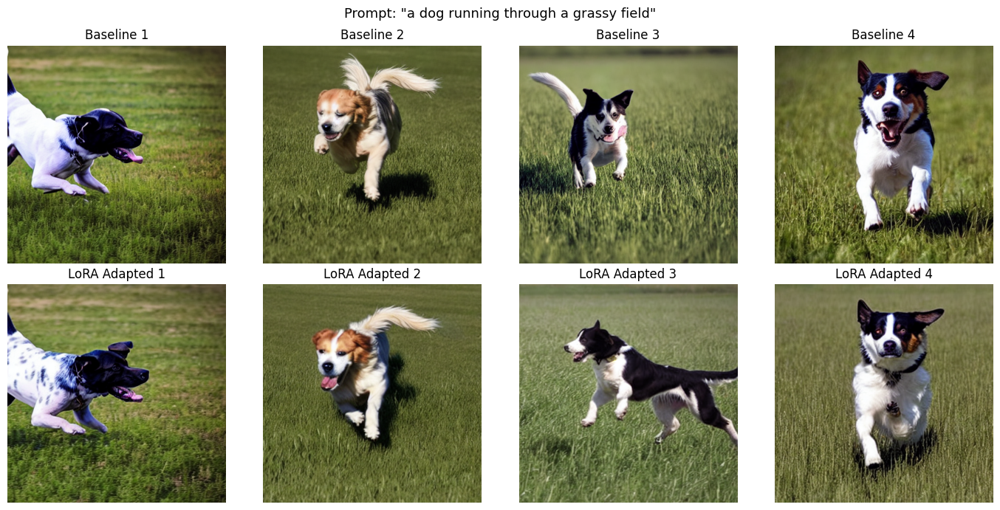

In [16]:
# Display controlled comparison

fig, axes = plt.subplots(
    2,
    NUM_SAMPLES,
    figsize=(14, 7)
)

for i in range(NUM_SAMPLES):

    axes[0, i].imshow(
        baseline_eval[i]
    )

    axes[0, i].set_title(
        f"Baseline {i + 1}"
    )

    axes[0, i].axis("off")

    axes[1, i].imshow(
        adapted_eval[i]
    )

    axes[1, i].set_title(
        f"LoRA Adapted {i + 1}"
    )

    axes[1, i].axis("off")

axes[0, 0].set_ylabel(
    "Pretrained",
    fontsize=12
)

axes[1, 0].set_ylabel(
    "Adapted",
    fontsize=12
)

plt.suptitle(
    f'Prompt: "{comparison_prompt}"',
    fontsize=13
)

plt.tight_layout()
plt.show()

In [17]:
# Save controlled comparison metadata

import os
import pandas as pd

evaluation_records = []

for i in range(NUM_SAMPLES):
    evaluation_records.append({
        "sample": i + 1,
        "prompt": comparison_prompt,
        "seed": SEED + 100 + i,
        "baseline_image": f"baseline_eval_{i + 1}.png",
        "adapted_image": f"adapted_eval_{i + 1}.png"
    })

evaluation_df = pd.DataFrame(evaluation_records)

evaluation_path = os.path.join(
    TASK1_DIR,
    "controlled_comparison_results.csv"
)

evaluation_df.to_csv(
    evaluation_path,
    index=False
)

print("Controlled comparison results saved.")
print("Records:", len(evaluation_df))
print("File:", evaluation_path)

display(evaluation_df)

Controlled comparison results saved.
Records: 4
File: /content/text_to_image_task1/controlled_comparison_results.csv


,sample,prompt,seed,baseline_image,adapted_image
0,1,a dog running through a grassy field,142,baseline_eval_1.png,adapted_eval_1.png
1,2,a dog running through a grassy field,143,baseline_eval_2.png,adapted_eval_2.png
2,3,a dog running through a grassy field,144,baseline_eval_3.png,adapted_eval_3.png
3,4,a dog running through a grassy field,145,baseline_eval_4.png,adapted_eval_4.png


In [18]:
# Save controlled comparison images

comparison_dir = os.path.join(
    TASK1_DIR,
    "controlled_comparison"
)

os.makedirs(comparison_dir, exist_ok=True)

for i in range(NUM_SAMPLES):

    baseline_eval[i].save(
        os.path.join(
            comparison_dir,
            f"baseline_eval_{i + 1}.png"
        )
    )

    adapted_eval[i].save(
        os.path.join(
            comparison_dir,
            f"adapted_eval_{i + 1}.png"
        )
    )

print("Controlled comparison images saved.")
print("Number of pairs:", NUM_SAMPLES)
print("Directory:", comparison_dir)

Controlled comparison images saved.
Number of pairs: 4
Directory: /content/text_to_image_task1/controlled_comparison


## Task 1 Findings and Analysis

The pretrained Stable Diffusion v1.5 model was adapted using LoRA on a balanced custom animal dataset containing cats, dogs, and snakes.

A controlled comparison was performed using the same prompt and random seeds for both the pretrained and LoRA-adapted models.

### Observations

- The pretrained model generated general-purpose dog images based on the evaluation prompt.
- The LoRA-adapted model also preserved the main semantic meaning of the prompt.
- The adapted outputs showed changes in visual characteristics compared with the pretrained outputs, demonstrating that the learned LoRA weights influenced generation.
- The experiment was performed with identical prompts and seeds to make the qualitative comparison more controlled.
- The generated samples were inspected for animal concept consistency, visual changes, prompt preservation, and possible overfitting.
- No unsupported claim of quantitative improvement is made because this experiment primarily evaluates visual/domain adaptation rather than using a dedicated image-quality benchmark.

### Limitations

- The training subset contained only 60 images.
- Only three animal categories were used: cats, dogs, and snakes.
- Training was performed for a limited number of steps.
- Evaluation was primarily qualitative.
- A larger dataset and standardized metrics such as CLIP-based similarity or image-quality measures could provide stronger quantitative evidence.

### Conclusion

The experiment demonstrates the process of adapting a pretrained text-to-image model to a custom visual domain using LoRA. The resulting adapted model can generate images from text prompts while incorporating learned characteristics from the custom animal dataset.

In [20]:
# Final Task 1 verification

import os

required_paths = {
    "Training images": "/content/text_to_image_task1/training_images",
    "LoRA weights": "/content/text_to_image_task1/lora_weights",
    "Baseline outputs": "/content/text_to_image_task1/baseline_outputs",
    "Adapted outputs": "/content/text_to_image_task1/adapted_outputs",
    "Controlled comparison": "/content/text_to_image_task1/controlled_comparison",
    "Evaluation CSV": "/content/text_to_image_task1/controlled_comparison_results.csv"
}

print("TASK 1 FINAL VERIFICATION")
print("=" * 50)

all_verified = True

for name, path in required_paths.items():
    exists = os.path.exists(path)

    if exists and os.path.isdir(path):
        files = os.listdir(path)
        print(f"{name}: PASS ({len(files)} files)")
    elif exists:
        print(f"{name}: PASS")
    else:
        print(f"{name}: MISSING")
        all_verified = False

print("=" * 50)

if all_verified:
    print("TASK 1 VERIFICATION: PASSED")
else:
    print("TASK 1 VERIFICATION: CHECK MISSING ITEMS")

TASK 1 FINAL VERIFICATION
Training images: PASS (61 files)
LoRA weights: PASS (5 files)
Baseline outputs: PASS (6 files)
Adapted outputs: PASS (6 files)
Controlled comparison: PASS (8 files)
Evaluation CSV: PASS
TASK 1 VERIFICATION: PASSED


In [21]:
# Package Task 1 results for transfer to VS Code

import shutil
import os

TASK1_DIR = "/content/text_to_image_task1"
EXPORT_DIR = "/content/task1_github_export"

os.makedirs(EXPORT_DIR, exist_ok=True)

items_to_copy = [
    "baseline_outputs",
    "adapted_outputs",
    "controlled_comparison",
    "controlled_comparison_results.csv",
]

for item in items_to_copy:
    source = os.path.join(TASK1_DIR, item)
    destination = os.path.join(EXPORT_DIR, item)

    if os.path.exists(source):
        if os.path.isdir(source):
            shutil.copytree(source, destination, dirs_exist_ok=True)
        else:
            shutil.copy2(source, destination)

# Create ZIP
zip_path = shutil.make_archive(
    "/content/task1_github_export",
    "zip",
    EXPORT_DIR
)

print("Task 1 export created successfully.")
print("ZIP:", zip_path)

Task 1 export created successfully.
ZIP: /content/task1_github_export.zip


## Task 1 Conclusion

The pretrained Stable Diffusion v1.5 model was successfully customized for a domain-specific text-to-image generation task using LoRA (Low-Rank Adaptation). A balanced custom animal dataset containing cats, dogs, and snakes was prepared, with 60 training images and corresponding text descriptions.

The LoRA adapter was successfully trained for 300 steps and integrated with the pretrained Stable Diffusion pipeline. The adapted model successfully generated images from text prompts, demonstrating that the pretrained model could be extended using a small custom dataset without retraining the complete model.

A controlled comparison was also performed between the original pretrained model and the LoRA-adapted model using identical prompts and random seeds. This provided a consistent basis for observing changes introduced by domain adaptation. The adapted outputs preserved the main semantic meaning of the prompts while showing visual differences from the original pretrained outputs.

The experiment demonstrates the practical workflow of adapting a pretrained text-to-image model to a custom visual domain using LoRA. However, the results should be interpreted as a proof-of-concept because the training dataset was small, training was limited to 300 steps, and evaluation was primarily qualitative. Larger datasets, longer training, and standardized image-text evaluation metrics could provide stronger evidence in future experiments.

Overall, Task 1 successfully demonstrates pretrained text-to-image model customization using a custom dataset and LoRA-based domain adaptation.